In [1]:
import numpy as np
import sys
from pathlib import Path
import copy
from time import time

Base_Dir = './' # assuming we are in zeldovich-smearing/emulation/, else modify this
Code_Dir = Base_Dir + '../code/'
sys.path.append(Code_Dir)

from emulation import AgnosticEmulator

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

from getdist.mcsamples import MCSamples
import getdist.plots as gdplt
from getdist.gaussian_mixtures import GaussianND

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl+getdist setup done')
#mpl.rcParams.keys()

mpl+getdist setup done


***
# Agnostic $\leftrightarrow$ Cosmological Emulation
### Load and use forward and inverse emulators for model-agnostic BAO inference
***

## Setup

In [3]:
Cosmo = 'nucdm'  # one of ['lcdm','wcdm','nucdm','w0wacdm']
Flat = False    # whether or not to vary spatial curvature

Loc_Stem = 'emulators/'
Model_Name = 'shallow' # one of existing models, e.g., 'shallow','telescopic'

# these should match what was used when generating data samples
Z_Eval = 0.8
Scale_Planck18 = 6.0

# Set the variable below to True to perform the 'stringent' test of arXiv:2410.21374 
# which assesses the performance of the BiSequential basis in describing the chosen model.
# This can be done regardless of the existence of any emulator, 
# but needs test data to have been generated with 'save_xi':True.
Perform_Stringent_Test = True

# useful for plotting
CMap = plt.cm.plasma 
Save_Fig = True

# minimal setup dict needed to load AgnosticEmulator instance
setup = {'out_stem':Loc_Stem,'cosmo':Cosmo,'flat':Flat,'z_eval':Z_Eval,'scale_planck18':Scale_Planck18}

In [4]:
agem = AgnosticEmulator(setup=setup)

print('Parameter variations...')
for p in range(len(agem.keys_vary)):
    print('... '+agem.keys_vary[p]+': [{0:.3e},{1:.3e}]'.format(agem.param_mins[p],agem.param_maxs[p]))
print('---------------')

Agnostic emulator for BAO inference...
... will work in folder: emulators/scale6.0/z0.80/
... extracting basis functions as NN
... done
... evaluating 9 basis functions
... done
... setting up fiducial cosmology and sampling ranges
... setting up parameter variations for family: nucdm
... fiducial params:
... ... Om: 3.1530e-01
... ... h: 6.7370e-01
... ... As: 2.1010e-09
... ... ns: 9.6490e-01
... ... Ob: 4.9287e-02
... ... Ok: 0.0000e+00
... ... m_ncdm: 0.0000e+00
... setting minimum varied m_ncdm = 0.96 meV, which becomes non-relativistic at requested z = 0.800
... setup complete
0 min 3.28 seconds

Parameter variations...
... Om: [2.715e-01,3.591e-01]
... h: [6.413e-01,7.061e-01]
... As: [1.925e-09,2.277e-09]
... ns: [9.397e-01,9.901e-01]
... Ob: [4.415e-02,5.443e-02]
... Ok: [-7.500e-02,7.500e-02]
... m_ncdm: [9.558e-04,3.000e-01]
---------------


## Load 

### Data

In [5]:
if Perform_Stringent_Test:
    agnostic,cosmological,xilin = agem.gen_sample(sample_setup={'sample_stem':'test','save_xi':True})
else:
    agnostic,cosmological = agem.gen_sample(sample_setup={'sample_stem':'test'})

# exclude the few pathological examples (in neutrino cosmologies) with very large sigv values
ind_keep = np.where(agnostic[-3] < 1e3)[0]
print(cosmological[:,np.where(agnostic[-3] >= 1e3)[0]])
agnostic = agnostic[:,ind_keep]
cosmological = cosmological[:,ind_keep]
if Perform_Stringent_Test:
    xilin = xilin[ind_keep]
n_samp = agnostic.shape[1]
print('... kept {0:d} samples'.format(n_samp))

Generating/reading sample from: emulators/scale6.0/z0.80/nucdm/samples/test
... folder exists, attempting to read
... read 2000 samples
0 min 0.01 seconds

[[3.15102801e-01]
 [6.92387944e-01]
 [2.01139255e-09]
 [9.42322111e-01]
 [5.04258473e-02]
 [5.14382191e-02]
 [2.83843532e-01]]
... kept 1999 samples


#### Optional stringent test for basis set

[................... ] 100% done
16,50,84 pc residual: -6.352e-03,1.000e-04,7.992e-03
width: 7.172e-03
Saving to file: emulators/scale6.0/z0.80/nucdm/plots/stringent_test.pdf
0 min 0.30 seconds



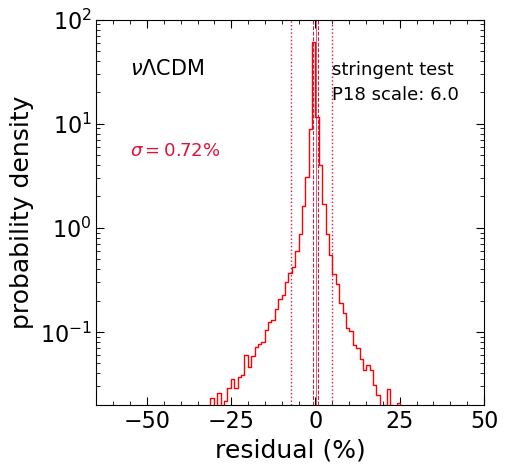

In [6]:
if Perform_Stringent_Test:
    Save_Fig_Stringent = True
    
    start_time = time()
    xilin_predict = np.zeros_like(xilin)
    for n in range(n_samp):
        xilin_predict[n] = np.dot(agem.basis_func.T,agnostic[:agem.n_basis,n])
        agem.status_bar(n,n_samp)

    residual_matrix = xilin_predict/(xilin + 1e-15) - 1
    residual = residual_matrix.flatten()

    print('16,50,84 pc residual: {0:.3e},{1:.3e},{2:.3e}'.format(np.percentile(residual,16),np.median(residual),
                                                                 np.percentile(residual,84)))
    width = 0.5*(np.percentile(residual,84)-np.percentile(residual,16))
    print('width: {0:.3e}'.format(width))

    bins=np.linspace(-1,1,200)
    bin_mid = 0.5*(bins[1:]+bins[:-1])
    
    hist,bins = np.histogram(residual,bins=bins,density=False)
    hist = hist/residual.size/(bins[1]-bins[0])
    
    FSize = 5
    plt.figure(figsize=(FSize,FSize))
    plt.yscale('log')
    plt.xlim(-65,50)
    plt.ylim(2e-2,1e2)
    plt.xlabel('residual (%)')
    plt.ylabel('probability density')
    plt.plot(bin_mid*100,hist,'r-',drawstyle='steps',lw=1)
    plt.text(-55,5,'$\\sigma = {0:.2f}\%$'.format(width*100),fontsize=FS3,c='crimson')
    plt.text(5,17,'P18 scale: {0:.1f}'.format(agem.scale_planck18),fontsize=FS3)
    plt.axvline(np.median(residual)*100,ls='-',lw=0.5,c='crimson')
    plt.axvline(np.percentile(residual,16)*100,ls='--',lw=0.75,c='crimson')
    plt.axvline(np.percentile(residual,84)*100,ls='--',lw=0.75,c='crimson')
    plt.axvline(np.percentile(residual,97.5)*100,ls=':',lw=1,c='crimson')
    plt.axvline(np.percentile(residual,2.5)*100,ls=':',lw=1,c='crimson')
    plt.text(-55,30,agem.cosmo_latex,fontsize=FS2)
    plt.text(5,30,'stringent test',fontsize=FS3)
    plt.minorticks_on()
    if Save_Fig_Stringent:
        outfile = agem.plot_dir + 'stringent_test.pdf'
        print('Saving to file:',outfile)
        plt.savefig(outfile,bbox_inches='tight')
    else:
        plt.show() 
    
    agem.time_this(start_time)

### Models

#### Forward

In [7]:
start_time = time()
FwdEmulator = agem.load(invert=False,model_name=Model_Name)
agem.time_this(start_time)
# FwdEmulator.display_summary()

Emulating forward mapping...
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... ... standard training will be implemented
... found data set of dimension 7 with targets of dimension 13
... found 1 samples
... fraction 0.800 (1 samples) will be used for training
... will search over 3 iterations of 10 configurations
... will store best 5 networks in ensemble
... will use residual percentiles for hyperparameter comparison
... setup complete
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
0 min 0.02 seconds



#### Inverse

In [8]:
start_time = time()
InvEmulator = agem.load(invert=True,model_name=Model_Name)
agem.time_this(start_time)
# InvEmulator.display_summary()

Emulating inverse mapping...
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... ... standard training will be implemented
... found data set of dimension 13 with targets of dimension 7
... found 1 samples
... fraction 0.800 (1 samples) will be used for training
... will search over 3 iterations of 10 configurations
... will store best 5 networks in ensemble
... will use residual percentiles for hyperparameter comparison
... setup complete
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
0 min 0.06 seconds



## Visualize parameter distributions
#### cf. 'strong' prior

In [9]:
def set_gdplot(sp_size=1.2):
    """ Convenience function for setting up GetDist plots. """
    gdplot = gdplt.get_subplot_plotter(subplot_size=1.2)
    gdplot.settings.num_plot_contours = 3
    gdplot.settings.axes_fontsize = FS3
    gdplot.settings.legend_fontsize = FS
    gdplot.settings.axes_labelsize = FS2
    gdplot.settings.title_limit_fontsize = FS2
    return gdplot

In [10]:
print('all varied params')
print(agem.keys_vary+agem.keys_agnostic)

# use subsets of plot_param_list_all and par_show_all to focus on specific parameter subsets.
# we showcase a few choices below.
plot_param_list_all = np.array(agem.keys_vary+agem.keys_agnostic)
par_show_all = np.arange(agem.n_params+agem.n_agnostic)
file_stem_all = 'contours'

# store concatenated sample for later use
sample = np.concatenate((cosmological,agnostic),axis=0).T

# load full sample in getdist
gd_sample = MCSamples(samples=sample,
                      names=agem.keys_vary+agem.keys_agnostic,
                      labels=agem.latex_cosmological+agem.latex_agnostic,
                      settings={'smooth_scale_2D':0.3},label='strong prior')

all varied params
['Om', 'h', 'As', 'ns', 'Ob', 'Ok', 'm_ncdm', 'w0', 'w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8', 'f', 'sigv', 'DaAP', 'fv']
Removed no burn in


### Full distribution

In [11]:
plot_param_list = plot_param_list_all.copy()
par_show = par_show_all.copy()
file_stem = file_stem_all + '_all'
print(plot_param_list)

['Om' 'h' 'As' 'ns' 'Ob' 'Ok' 'm_ncdm' 'w0' 'w1' 'w2' 'w3' 'w4' 'w5' 'w6'
 'w7' 'w8' 'f' 'sigv' 'DaAP' 'fv']


Writing to file: emulators/scale6.0/z0.80/nucdm/plots/contours_all.pdf
0 min 12.45 seconds



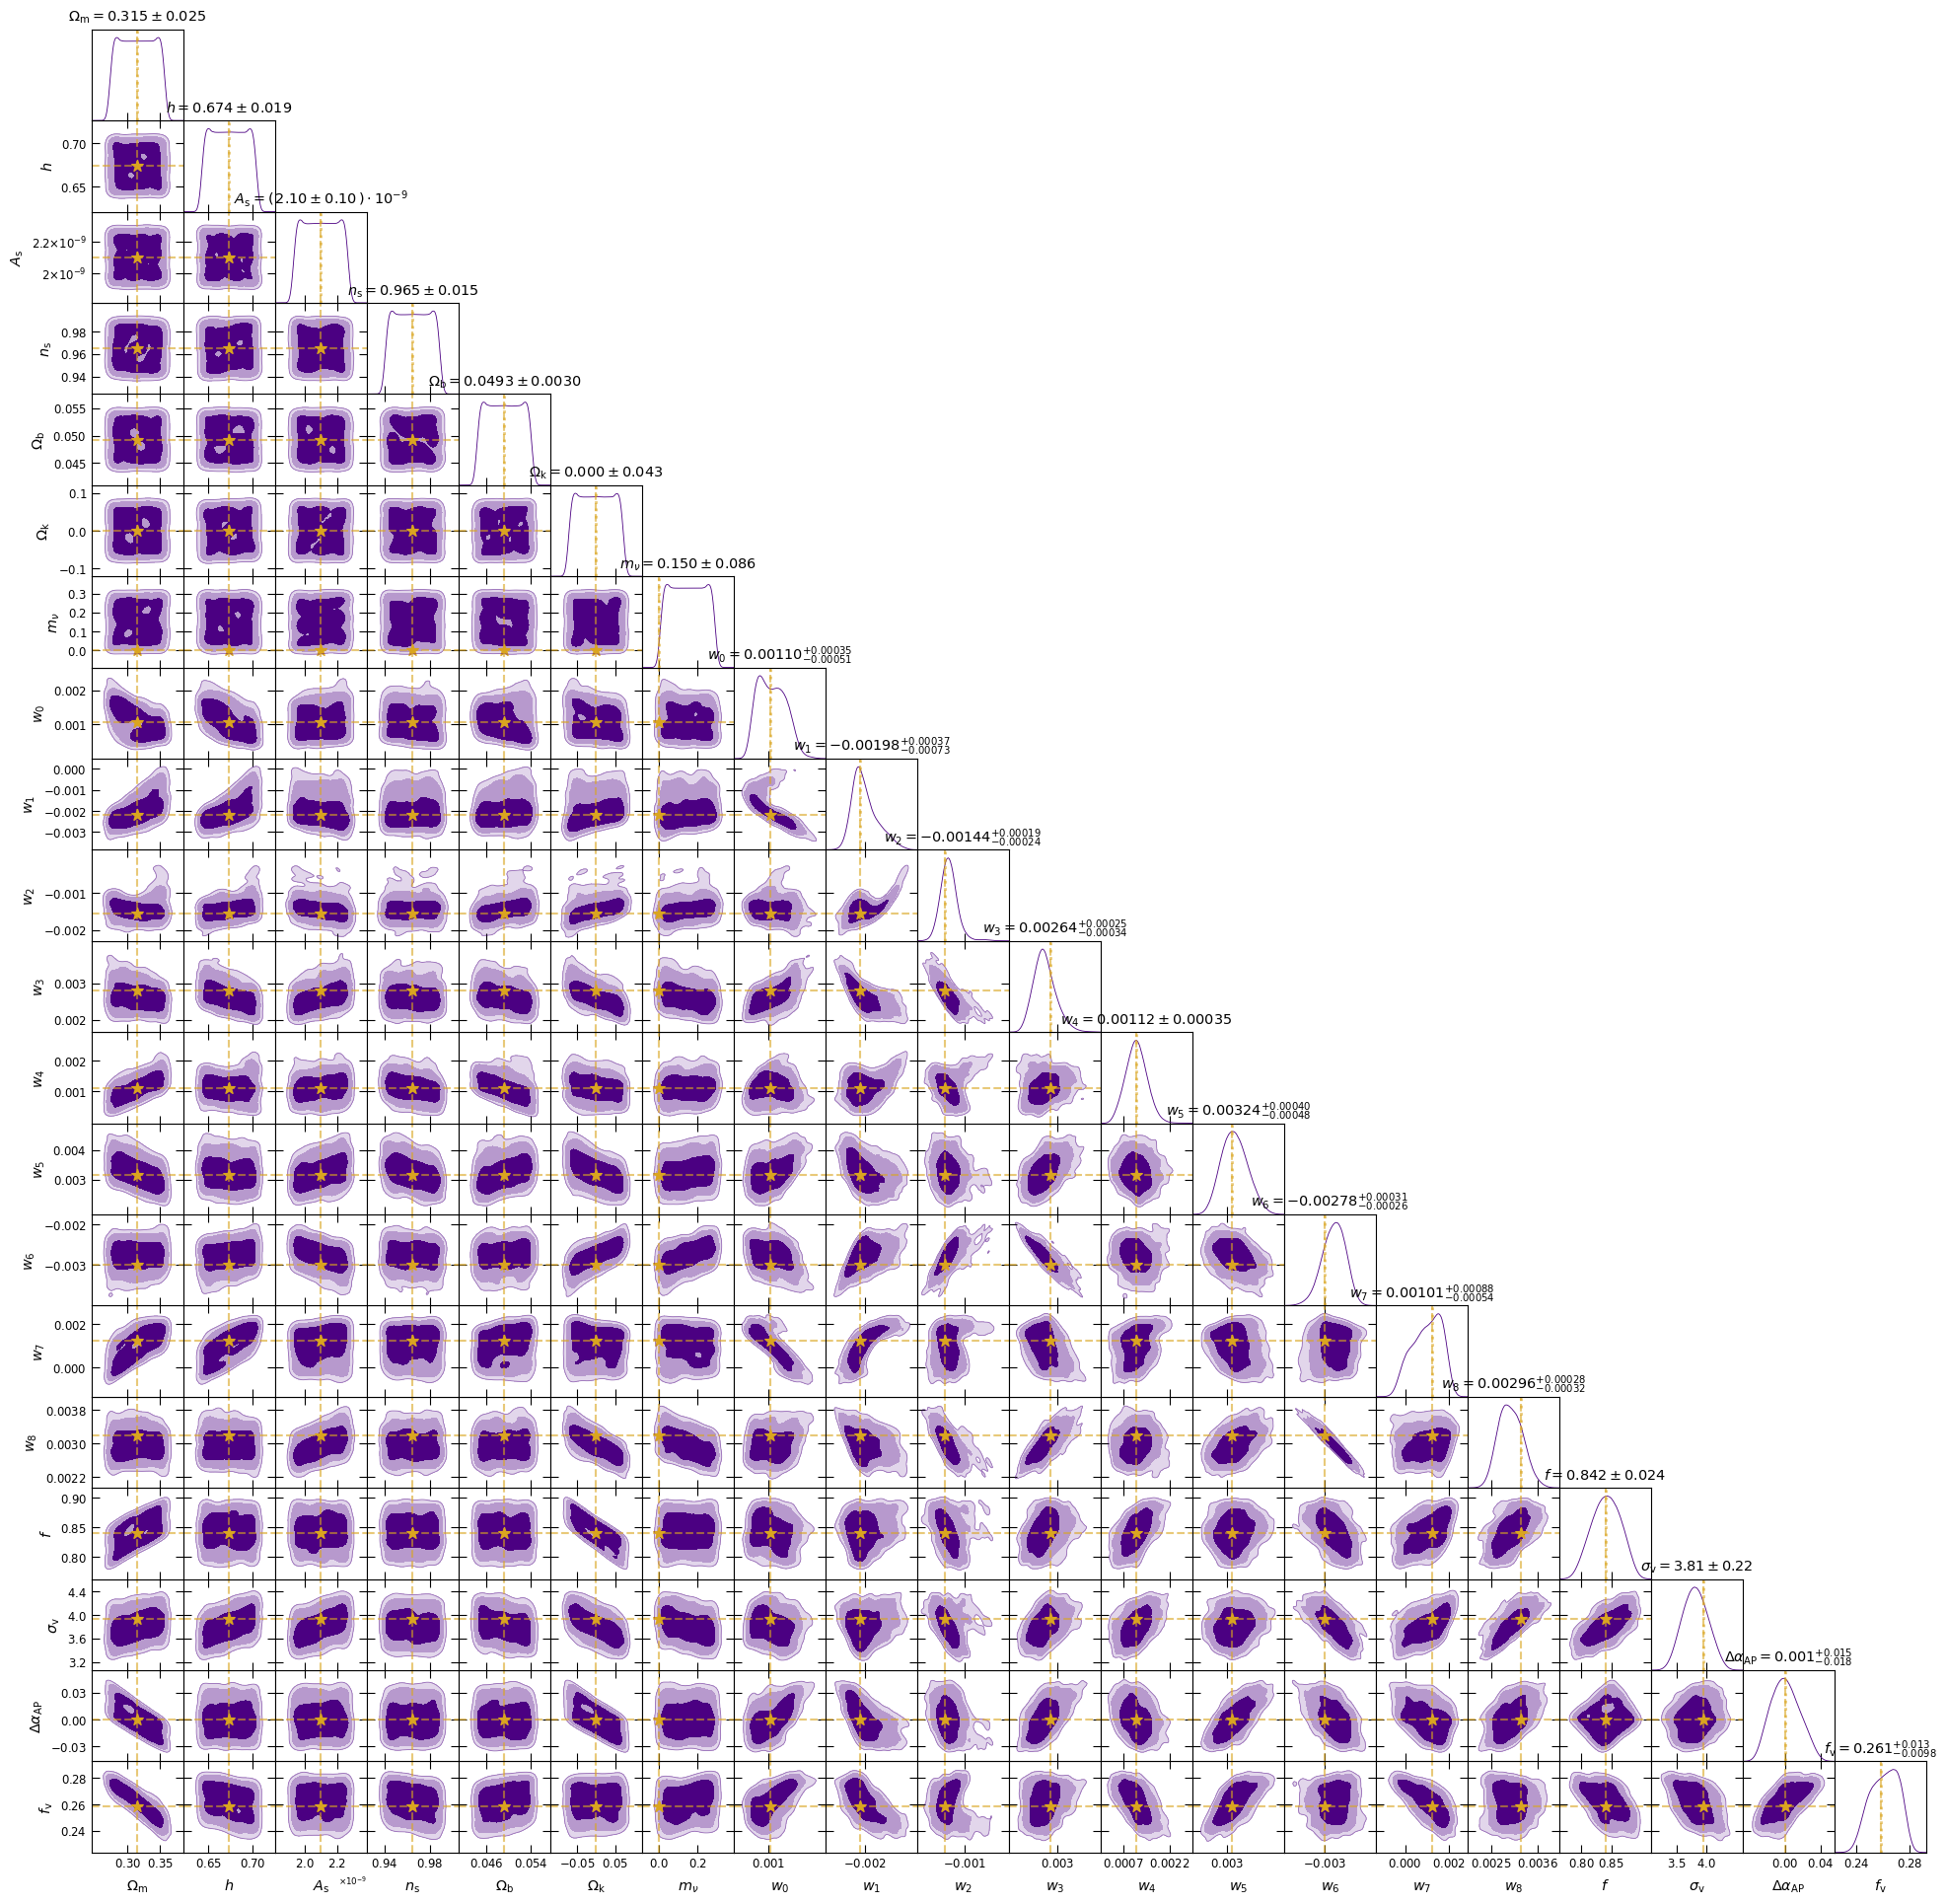

In [12]:
start_time = time()
gdplot = set_gdplot(sp_size=1.2)

gdplot.triangle_plot([gd_sample], plot_param_list,
                     filled=[True],contour_colors=['indigo'],legend_loc='upper center',
                     markers=sample[-1][par_show],
                     marker_args={'c': 'goldenrod','ls': '--','lw': 1.5,'alpha': 0.6},
                     title_limit=1)

for par_y in range(par_show.size):
    str_y = plot_param_list[par_y]
    ax = gdplot.subplots[par_y,par_y]
    ax.axvline(sample[-1][par_show][par_y],c='goldenrod',ls=':',lw=2.0,alpha=0.6)
    for par_x in range(par_y):
        str_x = plot_param_list[par_x]
        ax = gdplot.subplots[par_y,par_x]
        ax.scatter([sample[-1][par_show][par_x]],[sample[-1][par_show][par_y]],
                   marker='*',s=75,c='goldenrod')
        
if Save_Fig:
    filename = file_stem + '.pdf'
    print('Writing to file: '+agem.plot_dir+filename)
    gdplot.export(fname=filename,adir=agem.plot_dir)

agem.time_this(start_time)

### Basis coefficients

In [13]:
sl = np.r_[agem.n_params:agem.n_params+agem.n_basis]
plot_param_list = plot_param_list_all[sl]
par_show = par_show_all[sl]
file_stem = file_stem_all + '_coeffs'
print(plot_param_list)

['w0' 'w1' 'w2' 'w3' 'w4' 'w5' 'w6' 'w7' 'w8']


Writing to file: emulators/scale6.0/z0.80/nucdm/plots/contours_coeffs.pdf
0 min 2.87 seconds



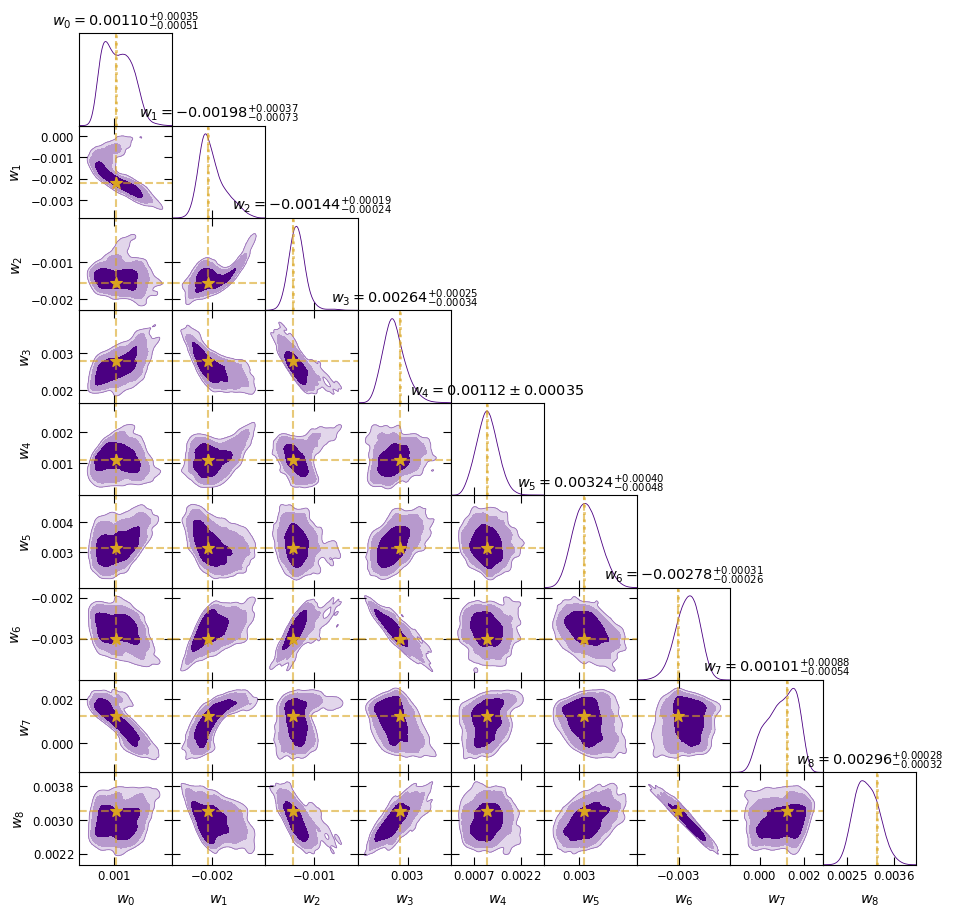

In [14]:
start_time = time()
gdplot = set_gdplot(sp_size=1.8)

gdplot.triangle_plot([gd_sample], plot_param_list,
                     filled=[True],contour_colors=['indigo'],legend_loc='upper center',
                     markers=sample[-1][par_show],
                     marker_args={'c': 'goldenrod','ls': '--','lw': 1.5,'alpha': 0.6},
                     title_limit=1)

for par_y in range(par_show.size):
    str_y = plot_param_list[par_y]
    ax = gdplot.subplots[par_y,par_y]
    ax.axvline(sample[-1][par_show][par_y],c='goldenrod',ls=':',lw=2.0,alpha=0.6)
    for par_x in range(par_y):
        str_x = plot_param_list[par_x]
        ax = gdplot.subplots[par_y,par_x]
        ax.scatter([sample[-1][par_show][par_x]],[sample[-1][par_show][par_y]],
                   marker='*',s=75,c='goldenrod')
        
if Save_Fig:
    filename = file_stem + '.pdf'
    print('Writing to file: '+agem.plot_dir+filename)
    gdplot.export(fname=filename,adir=agem.plot_dir)

agem.time_this(start_time)

### Zel'dovich smearing and AP

In [15]:
sl = np.s_[agem.n_params+agem.n_basis:]
plot_param_list = plot_param_list_all[sl]
par_show = par_show_all[sl]
file_stem = file_stem_all + '_zelsmear_AP'
print(plot_param_list)

['f' 'sigv' 'DaAP' 'fv']


Writing to file: emulators/scale6.0/z0.80/nucdm/plots/contours_zelsmear_AP.pdf
0 min 0.65 seconds



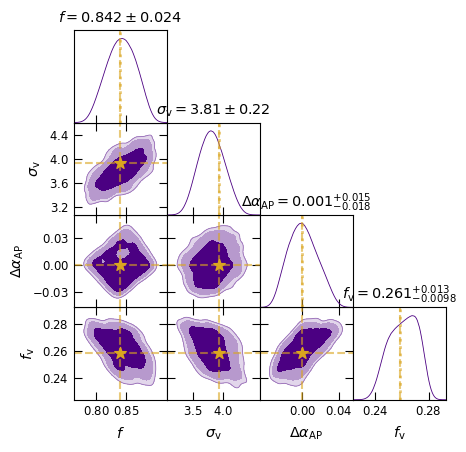

In [16]:
start_time = time()
gdplot = set_gdplot(sp_size=1.8)

gdplot.triangle_plot([gd_sample], plot_param_list,
                     filled=[True],contour_colors=['indigo'],legend_loc='upper center',
                     markers=sample[-1][par_show],
                     marker_args={'c': 'goldenrod','ls': '--','lw': 1.5,'alpha': 0.6},
                     title_limit=1)

for par_y in range(par_show.size):
    str_y = plot_param_list[par_y]
    ax = gdplot.subplots[par_y,par_y]
    ax.axvline(sample[-1][par_show][par_y],c='goldenrod',ls=':',lw=2.0,alpha=0.6)
    for par_x in range(par_y):
        str_x = plot_param_list[par_x]
        ax = gdplot.subplots[par_y,par_x]
        ax.scatter([sample[-1][par_show][par_x]],[sample[-1][par_show][par_y]],
                   marker='*',s=75,c='goldenrod')
        
if Save_Fig:
    filename = file_stem + '.pdf'
    print('Writing to file: '+agem.plot_dir+filename)
    gdplot.export(fname=filename,adir=agem.plot_dir)

agem.time_this(start_time)

## Predictive performance

In [17]:
bins = np.linspace(-1,1,400)
bin_mid = 0.5*(bins[1:]+bins[:-1])
dx = bins[1]-bins[0]

### Predictions obtained by a simple call to `predict` method
#### $\theta_{\rm agnostic,predicted} = \texttt{FwdEmulator.predict}(\theta_{\rm cosmological})$
#### $\theta_{\rm cosmological,predicted} = \texttt{InvEmulator.predict}(\theta_{\rm agnostic})$

In [18]:
start_time = time()
print('Predictions...')
agnostic_predict = FwdEmulator.predict(cosmological)
cosmological_predict = InvEmulator.predict(agnostic)
agem.time_this(start_time)

Predictions...
0 min 0.29 seconds



### Flattened residuals

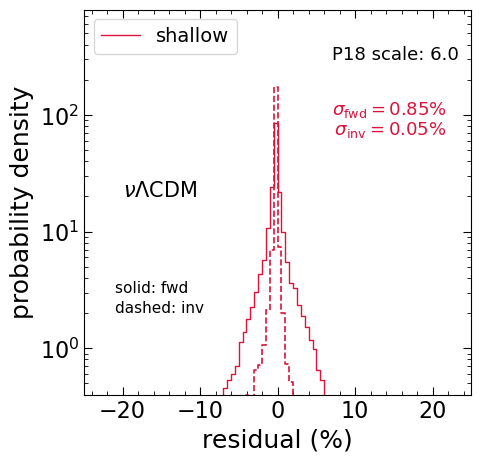

In [19]:
###########################
# these were also produced by Build_Emulators.ipynb
###########################
err_agnos = (agnostic_predict/(agnostic + 1e-15) - 1).flatten()
err_agnos = err_agnos[np.isfinite(err_agnos)]
errwidth_agnos = 0.5*(np.percentile(err_agnos,84)-np.percentile(err_agnos,16))

err_cosmo = (cosmological_predict/(cosmological + 1e-15) - 1).flatten()
err_cosmo = err_cosmo[np.isfinite(err_cosmo)]
errwidth_cosmo = 0.5*(np.percentile(err_cosmo,84)-np.percentile(err_cosmo,16))

hist_agnos,dummy = np.histogram(err_agnos,bins=bins,density=False)
hist_agnos = hist_agnos/err_agnos.size/dx
hist_cosmo,dummy = np.histogram(err_cosmo,bins=bins,density=False)
hist_cosmo = hist_cosmo/err_cosmo.size/dx

FSize = 5
plt.figure(figsize=(FSize,FSize))
plt.yscale('log')
plt.xlim(-25,25)
plt.ylim(4e-1,8e2)
plt.xlabel('residual (%)')
plt.ylabel('probability density')
Xt,Yf,Yi = 7,40,27
plt.plot(bin_mid*100,hist_agnos,ls='-',c='crimson',drawstyle='steps',lw=1,label=Model_Name)
plt.plot(bin_mid*100,hist_cosmo,ls='--',c='crimson',drawstyle='steps',lw=1.2)
plt.text(Xt,Yf*2.5,'$\\sigma_{{\\rm fwd}} = {0:.2f}\%$'.format(100*errwidth_agnos),fontsize=FS3,c='crimson')
plt.text(Xt,Yi*2.5,'$\\,\\sigma_{{\\rm inv}} = {0:.2f}\%$'.format(100*errwidth_cosmo),fontsize=FS3,c='crimson')
plt.legend(loc='upper left')
plt.text(-20,20,agem.cosmo_latex,fontsize=FS2)
plt.text(Xt,3e2,'P18 scale: {0:.1f}'.format(agem.scale_planck18),fontsize=FS3)
plt.text(-21,3,'solid: fwd',fontsize=11)
plt.text(-21,2,'dashed: inv',fontsize=11)
plt.minorticks_on()
plt.show()

### Parameter-wise residuals

In [20]:
err_agnos = (agnostic_predict/(agnostic + 1e-15) - 1)
errwidth_agnos = 0.5*(np.percentile(err_agnos,84,axis=1)-np.percentile(err_agnos,16,axis=1))
err_cosmo = (cosmological_predict/(cosmological + 1e-15) - 1)
errwidth_cosmo = 0.5*(np.percentile(err_cosmo,84,axis=1)-np.percentile(err_cosmo,16,axis=1))
print('--------')
print('... '+Model_Name)
print('--------')
print('... ... forward')
for p in range(len(agem.keys_agnostic)):
    print(agem.keys_agnostic[p]+': {0:.3e}'.format(errwidth_agnos[p]))
print('--------')
print('... ... inverse')
for p in range(len(agem.keys_vary)):
    print(agem.keys_vary[p]+': {0:.3e}'.format(errwidth_cosmo[p]))
print('--------')

print('... forward error + covariance matrix')
fwd_error = agnostic_predict-agnostic 
fwd_error_shifted = fwd_error + agnostic[:,-1:]
cov_agnos = np.cov(fwd_error)
cov_file = agem.out_stem + agem.cosmo + agem.flat_str + '/models/' + Model_Name + '_forward/cov.txt'
print('... ... writing covariance to file: '+cov_file)
np.savetxt(cov_file,cov_agnos,fmt='%.8e')

print('... getdist sample')
gd_err_agnos_shifted = MCSamples(samples=fwd_error_shifted.T,
                                 names=agem.keys_agnostic,
                                 labels=agem.latex_agnostic,
                                 settings={'smooth_scale_2D':0.3},label='forward error')
gd_err_agnos = MCSamples(samples=fwd_error.T,
                         names=agem.keys_agnostic,
                         labels=agem.latex_agnostic,
                         settings={'smooth_scale_2D':0.3},label='forward error')
print('... done')

--------
... shallow
--------
... ... forward
w0: 4.098e-02
w1: 1.435e-02
w2: 2.877e-02
w3: 3.544e-03
w4: 3.216e-02
w5: 7.230e-03
w6: 4.185e-03
w7: 1.399e-02
w8: 5.369e-03
f: 5.220e-05
sigv: 1.307e-04
DaAP: 3.616e-03
fv: 1.211e-04
--------
... ... inverse
Om: 9.665e-05
h: 4.992e-05
As: 4.844e-04
ns: 2.525e-04
Ob: 1.798e-04
Ok: 1.843e-03
m_ncdm: 1.043e-02
--------
... forward error + covariance matrix
... ... writing covariance to file: emulators/scale6.0/z0.80/nucdm/models/shallow_forward/cov.txt
... getdist sample
Removed no burn in
Removed no burn in
... done


### Compare forward emulator error and strong prior

In [21]:
sl = np.s_[agem.n_params:]
plot_param_list = plot_param_list_all[sl]
par_show = par_show_all[sl]
file_stem = file_stem_all + '_errcompare'
print(plot_param_list)

['w0' 'w1' 'w2' 'w3' 'w4' 'w5' 'w6' 'w7' 'w8' 'f' 'sigv' 'DaAP' 'fv']


Writing to file: emulators/scale6.0/z0.80/nucdm/plots/contours_errcompare.pdf
0 min 7.40 seconds



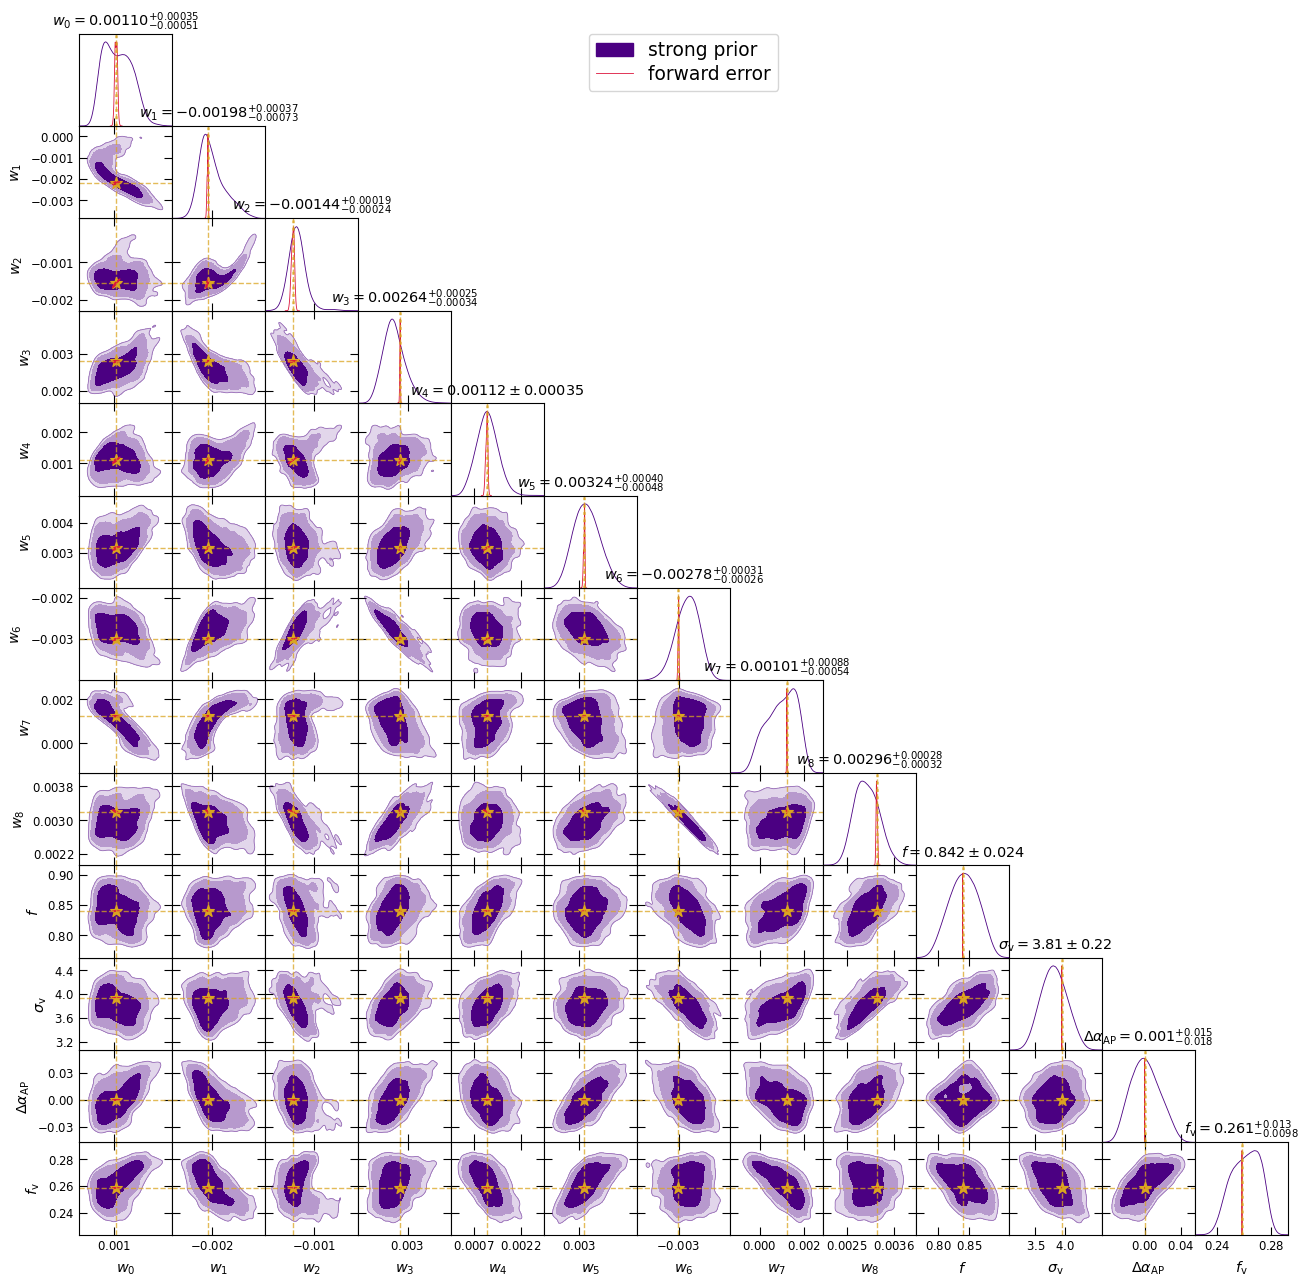

In [22]:
start_time = time()
gdplot = set_gdplot(sp_size=1.2)

gdplot.triangle_plot([gd_sample,gd_err_agnos_shifted], plot_param_list,
                     filled=[True,False],contour_colors=['indigo','crimson'],legend_loc='upper center',
                     markers=sample[-1][par_show],marker_args={'c': 'goldenrod','ls': '--','lw':1.0,'alpha':0.75},
                     title_limit=1)

for par_y in range(par_show.size):
    str_y = plot_param_list[par_y]
    ax = gdplot.subplots[par_y,par_y]
    ax.axvline(sample[-1][par_show][par_y],c='goldenrod',ls=':',lw=2.0,alpha=0.6)
    for par_x in range(par_y):
        str_x = plot_param_list[par_x]
        ax = gdplot.subplots[par_y,par_x]
        ax.scatter([sample[-1][par_show][par_x]],[sample[-1][par_show][par_y]],
                   marker='*',s=75,c='goldenrod')
        
if Save_Fig:
    filename = file_stem + '.pdf'
    print('Writing to file: '+agem.plot_dir+filename)
    gdplot.export(fname=filename,adir=agem.plot_dir)

agem.time_this(start_time)

### Forward error only

In [23]:
gd_err_agnos_gauss = GaussianND(np.zeros(agem.n_agnostic),cov_agnos,
                                names=agem.keys_agnostic,
                                labels=agem.latex_agnostic,
                                label='Gauss approx')

In [24]:
sl = np.s_[agem.n_params:]
plot_param_list = plot_param_list_all[sl]
par_show = par_show_all[sl]
file_stem = file_stem_all + '_fwderr'
print(plot_param_list)

['w0' 'w1' 'w2' 'w3' 'w4' 'w5' 'w6' 'w7' 'w8' 'f' 'sigv' 'DaAP' 'fv']


Writing to file: emulators/scale6.0/z0.80/nucdm/plots/contours_fwderr.pdf
0 min 13.45 seconds



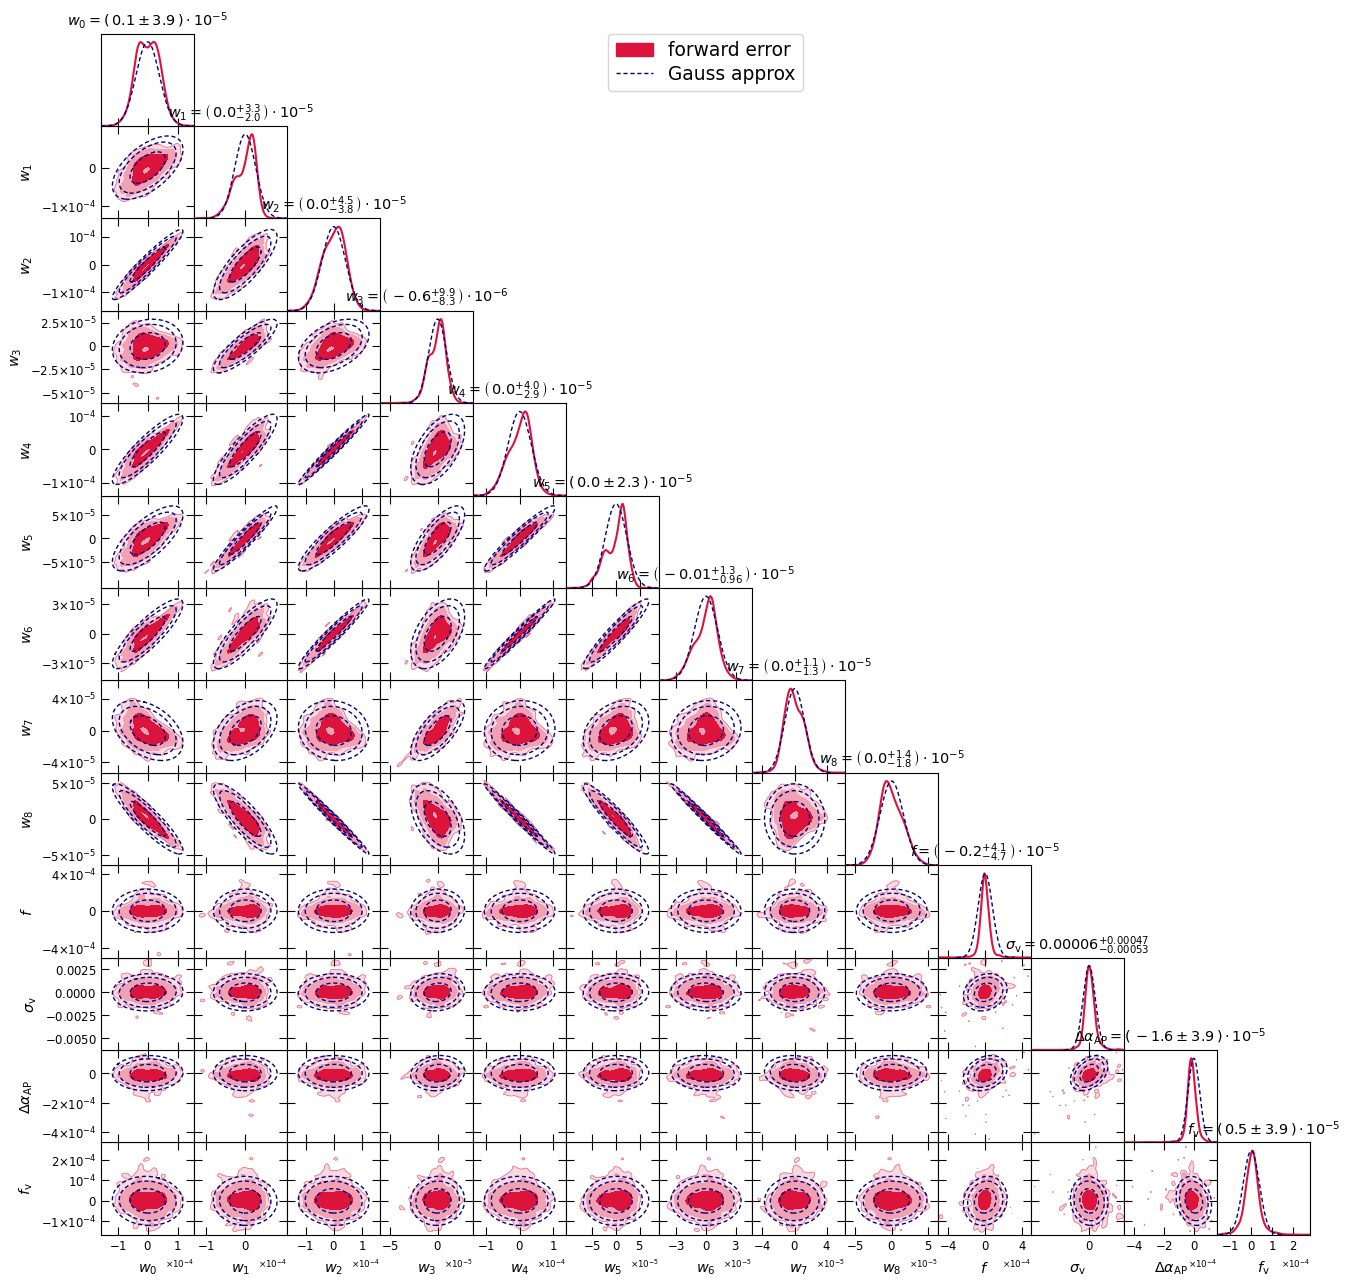

In [25]:
start_time = time()
gdplot = set_gdplot(sp_size=1.2)

gdplot.triangle_plot([gd_err_agnos,gd_err_agnos_gauss], plot_param_list,
                     filled=[True,False],contour_colors=['crimson','navy'],
                     contour_ls=['-','--'],
                     contour_lws=[1.5,1.0],
                     legend_loc='upper center',
                     title_limit=1)

if Save_Fig:
    filename = file_stem + '.pdf'
    print('Writing to file: '+agem.plot_dir+filename)
    gdplot.export(fname=filename,adir=agem.plot_dir)

agem.time_this(start_time)